<a href="https://colab.research.google.com/github/KiuPhuong/LTTC/blob/main/Transformer%20stock%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Đặt seed cho tái tạo kết quả
np.random.seed(42)
torch.manual_seed(42)


[*********************100%***********************]  1 of 1 completed

Đang tải dữ liệu cổ phiếu AAPL...
Dữ liệu có 2264 ngày, từ 2015-01-02 00:00:00 đến 2023-12-29 00:00:00

5 dòng dữ liệu đầu tiên:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.171755  24.638255  23.733996  24.627199  212818400
2015-01-05  23.490795  24.021411  23.305080  23.941819  257142000
2015-01-06  23.493011  23.751686  23.132634  23.554916  263188400
2015-01-07  23.822437  23.921927  23.590292  23.700837  160423600
2015-01-08  24.737743  24.795227  24.032466  24.149645  237458000


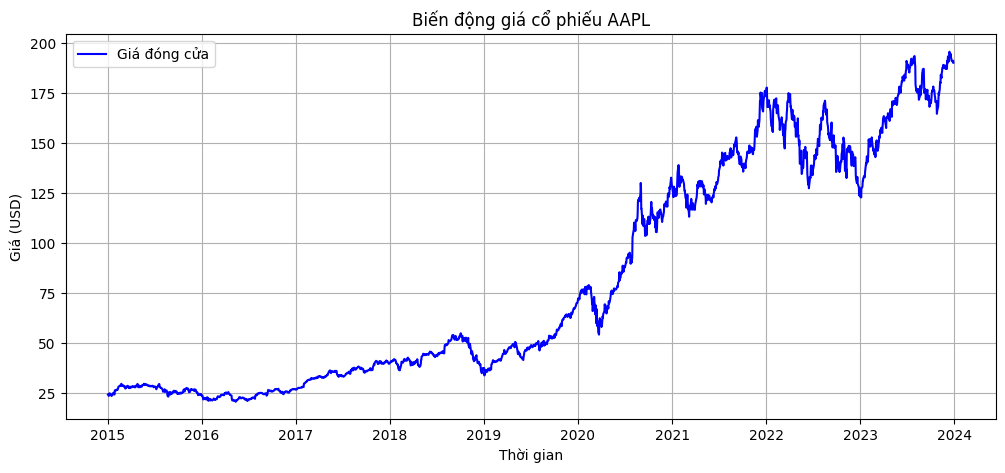

In [6]:
# Tải dữ liệu cổ phiếu Apple từ 2015-2024
ticker = 'AAPL'
start_date = '2015-01-01'
end_date = '2024-01-01'

print(f"Đang tải dữ liệu cổ phiếu {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date)
print(f"Dữ liệu có {len(df)} ngày, từ {df.index[0]} đến {df.index[-1]}")

# Xem 5 dòng đầu
print("\n5 dòng dữ liệu đầu tiên:")
print(df.head())

# Vẽ biểu đồ giá đóng cửa
plt.figure(figsize=(12, 5))
plt.plot(df['Close'], label='Giá đóng cửa', color='blue')
plt.title(f'Biến động giá cổ phiếu {ticker}')
plt.xlabel('Thời gian')
plt.ylabel('Giá (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Chỉ lấy cột giá đóng cửa
data = df[['Close']].values

# Chuẩn hóa dữ liệu về khoảng [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Hàm tạo sequences cho Seq2Seq
def create_sequences(data, seq_length=60, pred_length=10):
    """
    Tạo các cặp dữ liệu (X, y) cho mô hình chuỗi thời gian
    - seq_length: số ngày quá khứ để dự đoán
    - pred_length: số ngày tương lai cần dự đoán
    """
    X, y = [], []
    for i in range(len(data) - seq_length - pred_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+pred_length])
    return np.array(X), np.array(y)

SEQ_LEN = 60      # Dùng 60 ngày quá khứ
PRED_LEN = 10     # Dự đoán 10 ngày tiếp theo

X, y = create_sequences(scaled_data, SEQ_LEN, PRED_LEN)
print(f"Shape của X: {X.shape}")  # (số mẫu, 60, 1)
print(f"Shape của y: {y.shape}")  # (số mẫu, 10, 1)

Shape của X: (2194, 60, 1)
Shape của y: (2194, 10, 1)


In [9]:
# Chia dữ liệu train/validation/test (theo thời gian)
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"Train: {X_train.shape[0]} mẫu, Val: {X_val.shape[0]} mẫu, Test: {X_test.shape[0]} mẫu")

Train: 1535 mẫu, Val: 329 mẫu, Test: 330 mẫu


In [11]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [12]:
class PositionalEncoding(nn.Module):
    """Mã hóa vị trí cho Transformer"""
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TransformerModel(nn.Module):
    """
    Mô hình Transformer cho dự đoán chuỗi thời gian
    - Dùng Encoder thuần túy (không có Decoder)
    - Đầu ra dự đoán song song PRED_LEN bước
    """
    def __init__(self, input_dim=1, d_model=128, nhead=8, num_layers=4,
                 dim_feedforward=256, dropout=0.1, pred_len=10):
        super().__init__()
        self.d_model = d_model
        self.pred_len = pred_len

        # Embedding đầu vào
        self.input_fc = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Đầu ra: dự đoán cho từng bước
        self.output_fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = self.input_fc(x)  # (batch, seq_len, d_model)
        x = self.pos_encoder(x)  # (batch, seq_len, d_model)
        x = self.transformer_encoder(x)  # (batch, seq_len, d_model)

        # Lấy đặc trưng của bước cuối cùng và lặp lại để dự đoán chuỗi
        x = x[:, -1, :]  # (batch, d_model)
        x = self.output_fc(x)  # (batch, 1)
        x = x.unsqueeze(1).repeat(1, self.pred_len, 1)  # (batch, pred_len, 1)
        return x

# Khởi tạo mô hình
model = TransformerModel(
    input_dim=1,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1,
    pred_len=PRED_LEN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Mô hình được khởi tạo trên: {device}")
print(f"Số tham số: {sum(p.numel() for p in model.parameters()):,}")

Mô hình được khởi tạo trên: cpu
Số tham số: 530,305


In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

# Vòng lặp huấn luyện
EPOCHS = 100
train_losses = []
val_losses = []

print("Bắt đầu huấn luyện...")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Cập nhật learning rate
    scheduler.step(val_loss)

    # In kết quả mỗi 10 epoch
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}, LR = {current_lr:.6f}")

print("Huấn luyện hoàn tất!")

Bắt đầu huấn luyện...
Epoch 10/100: Train Loss = 0.003401, Val Loss = 0.010020, LR = 0.001000
Epoch 20/100: Train Loss = 0.001762, Val Loss = 0.010897, LR = 0.000500
Epoch 30/100: Train Loss = 0.001437, Val Loss = 0.007801, LR = 0.000250
Epoch 40/100: Train Loss = 0.001260, Val Loss = 0.008130, LR = 0.000125
Epoch 50/100: Train Loss = 0.001113, Val Loss = 0.005798, LR = 0.000063
Epoch 60/100: Train Loss = 0.001070, Val Loss = 0.007067, LR = 0.000063
Epoch 70/100: Train Loss = 0.001023, Val Loss = 0.007036, LR = 0.000031
Epoch 80/100: Train Loss = 0.001036, Val Loss = 0.006897, LR = 0.000016
Epoch 90/100: Train Loss = 0.000997, Val Loss = 0.006532, LR = 0.000008
Epoch 100/100: Train Loss = 0.001018, Val Loss = 0.006689, LR = 0.000004
Huấn luyện hoàn tất!


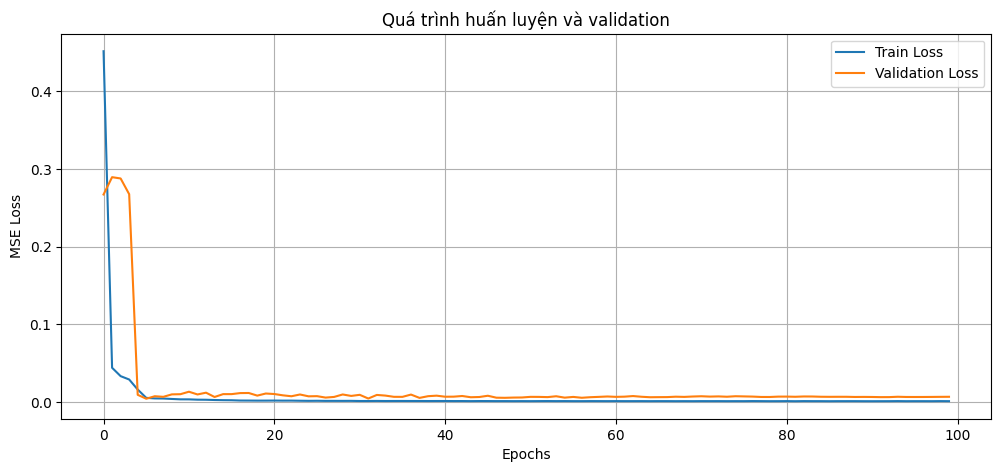

In [14]:
# Vẽ biểu đồ loss
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.title('Quá trình huấn luyện và validation')
plt.show()

In [15]:
test_loss = evaluate(model, test_loader, criterion, device)
print(f"Loss trên tập test: {test_loss:.6f}")

# Dự đoán trên toàn bộ tập test
model.eval()
all_preds = []
all_trues = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        all_preds.append(pred)
        all_trues.append(y_batch.numpy())

predictions = np.concatenate(all_preds, axis=0)
actuals = np.concatenate(all_trues, axis=0)

# Tính các chỉ số đánh giá
mse = mean_squared_error(actuals.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals.flatten(), predictions.flatten())
r2 = r2_score(actuals.flatten(), predictions.flatten())

print("\n=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R² Score: {r2:.4f}")

Loss trên tập test: 0.018732

=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===
MSE: 0.014400
RMSE: 0.120001
MAE: 0.101678
R² Score: -0.1997


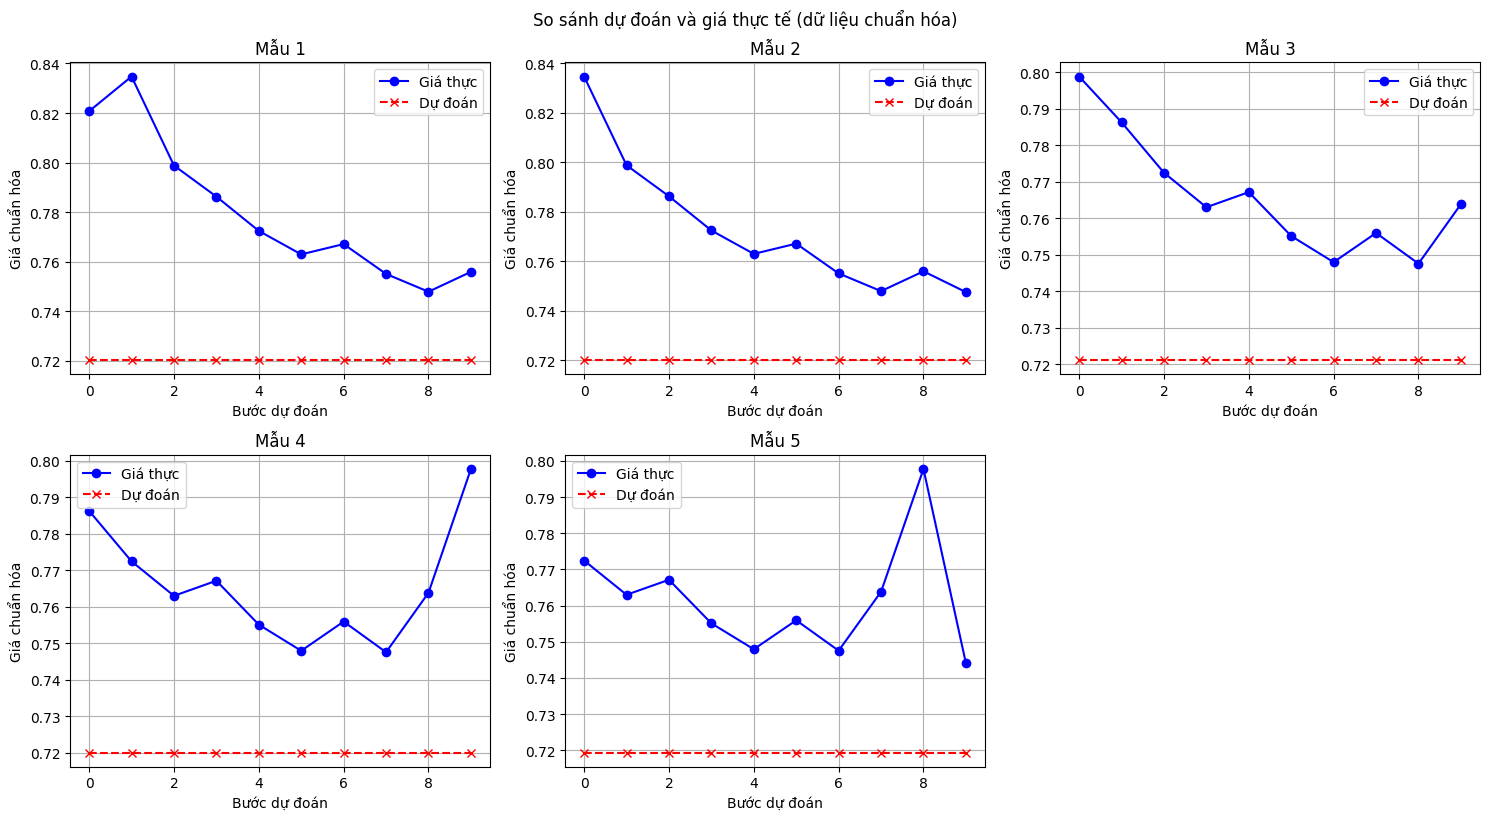

In [16]:
# Vẽ dự đoán cho vài mẫu đầu tiên
num_samples = 5
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(2, 3, i+1)
    plt.plot(actuals[i], label='Giá thực', color='blue', marker='o')
    plt.plot(predictions[i], label='Dự đoán', color='red', linestyle='--', marker='x')
    plt.title(f'Mẫu {i+1}')
    plt.xlabel('Bước dự đoán')
    plt.ylabel('Giá chuẩn hóa')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.suptitle('So sánh dự đoán và giá thực tế (dữ liệu chuẩn hóa)', y=1.02)
plt.show()

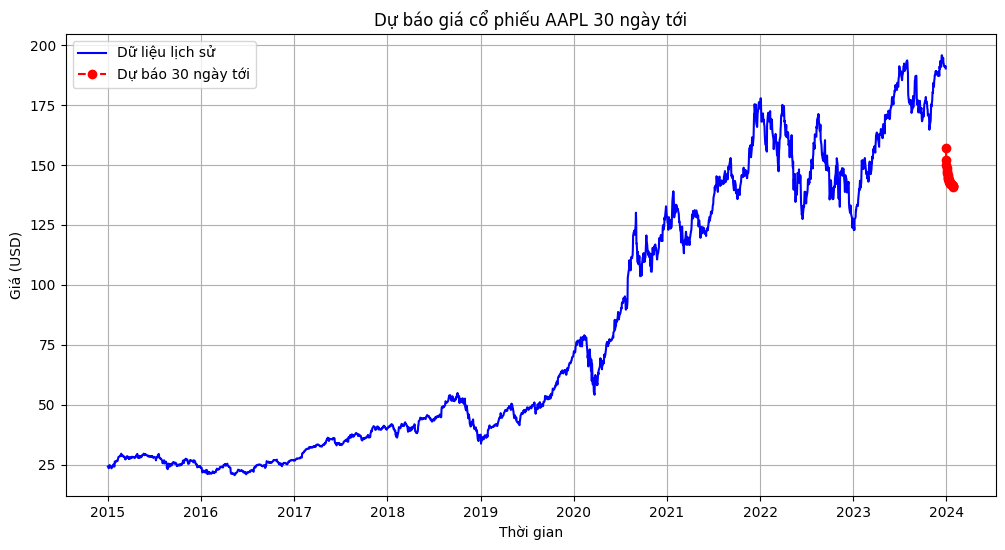

In [17]:
def predict_future(model, last_sequence, scaler, days_to_predict=30):
    """
    Dự báo nhiều ngày tiếp theo bằng cách tự hồi quy
    """
    model.eval()
    current_seq = last_sequence.copy()  # (60, 1) đã chuẩn hóa
    future_preds = []

    with torch.no_grad():
        for _ in range(days_to_predict):
            # Đưa vào mô hình
            input_tensor = torch.FloatTensor(current_seq).unsqueeze(0).to(device)  # (1, 60, 1)
            pred = model(input_tensor)  # (1, 10, 1)

            # Lấy dự đoán ngày tiếp theo (ngày đầu tiên trong 10 ngày)
            next_day = pred[0, 0, 0].item()
            future_preds.append(next_day)

            # Cập nhật chuỗi: thêm dự đoán mới và bỏ ngày cũ nhất
            current_seq = np.roll(current_seq, -1, axis=0)
            current_seq[-1] = next_day

    # Chuyển về giá trị thực
    future_preds = np.array(future_preds).reshape(-1, 1)
    future_prices = scaler.inverse_transform(future_preds)
    return future_prices

# Lấy 60 ngày cuối cùng trong dữ liệu
last_60_days = scaled_data[-60:].reshape(-1, 1)

# Dự báo 30 ngày tới
future_30 = predict_future(model, last_60_days, scaler, days_to_predict=30)

# Vẽ kết quả dự báo
plt.figure(figsize=(12, 6))
# Vẽ toàn bộ lịch sử
plt.plot(df.index, df['Close'], label='Dữ liệu lịch sử', color='blue')
# Vẽ dự báo tương lai
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30)
plt.plot(future_dates, future_30, label='Dự báo 30 ngày tới', color='red', linestyle='--', marker='o')
plt.title(f'Dự báo giá cổ phiếu {ticker} 30 ngày tới')
plt.xlabel('Thời gian')
plt.ylabel('Giá (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
class Backtester:
    """
    Hệ thống backtest cho chiến lược giao dịch dựa trên dự đoán giá
    """
    def __init__(self, initial_capital=10000, transaction_cost=0.001):
        """
        - initial_capital: vốn ban đầu (USD)
        - transaction_cost: chi phí giao dịch (0.1% cho mỗi lần mua/bán)
        """
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.capital = initial_capital
        self.positions = []  # Lịch sử vị thế
        self.trades = []     # Lịch sử giao dịch
        self.portfolio_values = []  # Giá trị danh mục theo thời gian

    def generate_signals(self, actual_prices, predicted_prices, threshold=0.005):
        """
        Tạo tín hiệu giao dịch dựa trên so sánh giữa giá thực tế và dự đoán
        - threshold: ngưỡng chênh lệch để phát tín hiệu (0.5%)
        """
        signals = []
        for i in range(len(predicted_prices)):
            # Nếu giá dự đoán cao hơn giá thực tế => tín hiệu MUA
            if predicted_prices[i] > actual_prices[i] * (1 + threshold):
                signals.append(1)  # Mua
            # Nếu giá dự đoán thấp hơn giá thực tế => tín hiệu BÁN
            elif predicted_prices[i] < actual_prices[i] * (1 - threshold):
                signals.append(-1)  # Bán
            else:
                signals.append(0)  # Không hành động
        return np.array(signals)

    def run_backtest(self, prices, signals):
        """
        Chạy backtest với giá và tín hiệu
        - prices: giá thực tế (đã được chuẩn hóa hoặc giá gốc)
        - signals: tín hiệu giao dịch (1: mua, -1: bán, 0: giữ)
        """
        self.capital = self.initial_capital
        self.portfolio_values = []
        self.trades = []
        self.positions = []

        position = 0  # 0: không nắm giữ, >0: đang nắm giữ
        entry_price = 0
        shares = 0

        for i, (price, signal) in enumerate(zip(prices, signals)):
            # Tính giá trị danh mục hiện tại
            if position > 0:
                portfolio_value = self.capital + shares * price
            else:
                portfolio_value = self.capital
            self.portfolio_values.append(portfolio_value)

            # Xử lý tín hiệu giao dịch
            if signal == 1 and position == 0:  # Mua
                shares_to_buy = int(self.capital * 0.95 / price)  # Dùng 95% vốn
                if shares_to_buy > 0:
                    cost = shares_to_buy * price * (1 + self.transaction_cost)
                    self.capital -= cost
                    shares = shares_to_buy
                    position = 1
                    entry_price = price
                    self.trades.append({
                        'date': i,
                        'type': 'BUY',
                        'price': price,
                        'shares': shares_to_buy,
                        'cost': cost
                    })

            elif signal == -1 and position > 0:  # Bán
                revenue = shares * price * (1 - self.transaction_cost)
                self.capital += revenue
                profit = revenue - (shares * entry_price)
                self.trades.append({
                    'date': i,
                    'type': 'SELL',
                    'price': price,
                    'shares': shares,
                    'revenue': revenue,
                    'profit': profit
                })
                self.positions.append({
                    'entry_date': self.trades[-2]['date'],
                    'exit_date': i,
                    'entry_price': entry_price,
                    'exit_price': price,
                    'profit': profit,
                    'return': (profit / (shares * entry_price)) * 100
                })
                shares = 0
                position = 0

        # Đóng vị thế cuối cùng nếu còn
        if position > 0:
            revenue = shares * prices[-1] * (1 - self.transaction_cost)
            self.capital += revenue
            profit = revenue - (shares * entry_price)
            self.trades.append({
                'date': len(prices)-1,
                'type': 'SELL (Close)',
                'price': prices[-1],
                'shares': shares,
                'revenue': revenue,
                'profit': profit
            })
            self.positions.append({
                'entry_date': self.trades[-2]['date'],
                'exit_date': len(prices)-1,
                'entry_price': entry_price,
                'exit_price': prices[-1],
                'profit': profit,
                'return': (profit / (shares * entry_price)) * 100
            })

        self.final_capital = self.capital + (shares * prices[-1] if position > 0 else 0)
        return self.portfolio_values

    def calculate_metrics(self, prices, risk_free_rate=0.02):
        """
        Tính các chỉ số đánh giá chiến lược
        """
        # Chuyển đổi portfolio_values thành DataFrame
        portfolio_df = pd.DataFrame({
            'date': range(len(self.portfolio_values)),
            'portfolio_value': self.portfolio_values,
            'price': prices[:len(self.portfolio_values)]
        })

        # 1. Cumulative Return
        total_return = (self.portfolio_values[-1] / self.initial_capital - 1) * 100

        # 2. Annualized Return (giả định 252 ngày giao dịch/năm)
        n_days = len(self.portfolio_values)
        annualized_return = ((self.portfolio_values[-1] / self.initial_capital) ** (252 / n_days) - 1) * 100

        # 3. Sharpe Ratio
        daily_returns = np.diff(self.portfolio_values) / self.portfolio_values[:-1]
        excess_returns = daily_returns - (risk_free_rate / 252)
        sharpe_ratio = np.sqrt(252) * np.mean(excess_returns) / np.std(daily_returns) if np.std(daily_returns) > 0 else 0

        # 4. Maximum Drawdown
        rolling_max = np.maximum.accumulate(self.portfolio_values)
        drawdown = (rolling_max - self.portfolio_values) / rolling_max * 100
        max_drawdown = np.max(drawdown)

        # 5. Win Rate
        if len(self.positions) > 0:
            winning_trades = sum(1 for p in self.positions if p['profit'] > 0)
            win_rate = (winning_trades / len(self.positions)) * 100
        else:
            win_rate = 0

        # 6. Number of Trades
        num_trades = len(self.positions)

        # Thêm các chỉ số phụ trợ
        avg_profit_per_trade = np.mean([p['profit'] for p in self.positions]) if self.positions else 0
        total_profit = sum([p['profit'] for p in self.positions])

        metrics = {
            'Cumulative Return (%)': round(total_return, 2),
            'Annualized Return (%)': round(annualized_return, 2),
            'Sharpe Ratio': round(sharpe_ratio, 3),
            'Maximum Drawdown (%)': round(max_drawdown, 2),
            'Win Rate (%)': round(win_rate, 2),
            'Number of Trades': num_trades,
            'Total Profit ($)': round(total_profit, 2),
            'Avg Profit per Trade ($)': round(avg_profit_per_trade, 2),
            'Final Capital ($)': round(self.final_capital, 2),
            'Transaction Cost (%)': self.transaction_cost * 100
        }

        return metrics, portfolio_df

In [19]:
# Chạy backtest trên tập test
backtester = Backtester(
    initial_capital=10000,
    transaction_cost=0.001  # 0.1% chi phí giao dịch
)

# Lấy dữ liệu test (đã chuyển về giá gốc)
test_prices_original = []
test_predictions_original = []

# Lấy từng mẫu trong test_loader
for X_batch, y_batch in test_loader:
    # Dự đoán cho từng batch
    with torch.no_grad():
        X_batch = X_batch.to(device)
        pred_batch = model(X_batch).cpu().numpy()

    # Chuyển đổi từ chuẩn hóa về giá gốc
    for i in range(len(y_batch)):
        # Lấy giá thực tế (chuỗi 10 ngày)
        actual_seq = y_batch[i].numpy().reshape(-1, 1)
        pred_seq = pred_batch[i].reshape(-1, 1)

        # Inverse transform về giá gốc
        actual_price = scaler.inverse_transform(actual_seq).flatten()
        pred_price = scaler.inverse_transform(pred_seq).flatten()

        test_prices_original.extend(actual_price)
        test_predictions_original.extend(pred_price)

# Chuyển thành numpy array
test_prices_original = np.array(test_prices_original)
test_predictions_original = np.array(test_predictions_original)

# Tạo tín hiệu giao dịch
signals = backtester.generate_signals(
    test_prices_original,
    test_predictions_original,
    threshold=0.01  # Ngưỡng 1%
)

# Chạy backtest
portfolio_values = backtester.run_backtest(test_prices_original, signals)

# Tính các chỉ số đánh giá
metrics, portfolio_df = backtester.calculate_metrics(test_prices_original)

print("=== KẾT QUẢ BACKTEST ===")
print("="*50)
for key, value in metrics.items():
    print(f"{key}: {value}")

=== KẾT QUẢ BACKTEST ===
Cumulative Return (%): 1145.1099853515625
Annualized Return (%): 21.239999771118164
Sharpe Ratio: 1.181
Maximum Drawdown (%): 8.17
Win Rate (%): 98.15
Number of Trades: 54
Total Profit ($): 116836.7265625
Avg Profit per Trade ($): 2163.639892578125
Final Capital ($): 124511.359375
Transaction Cost (%): 0.1


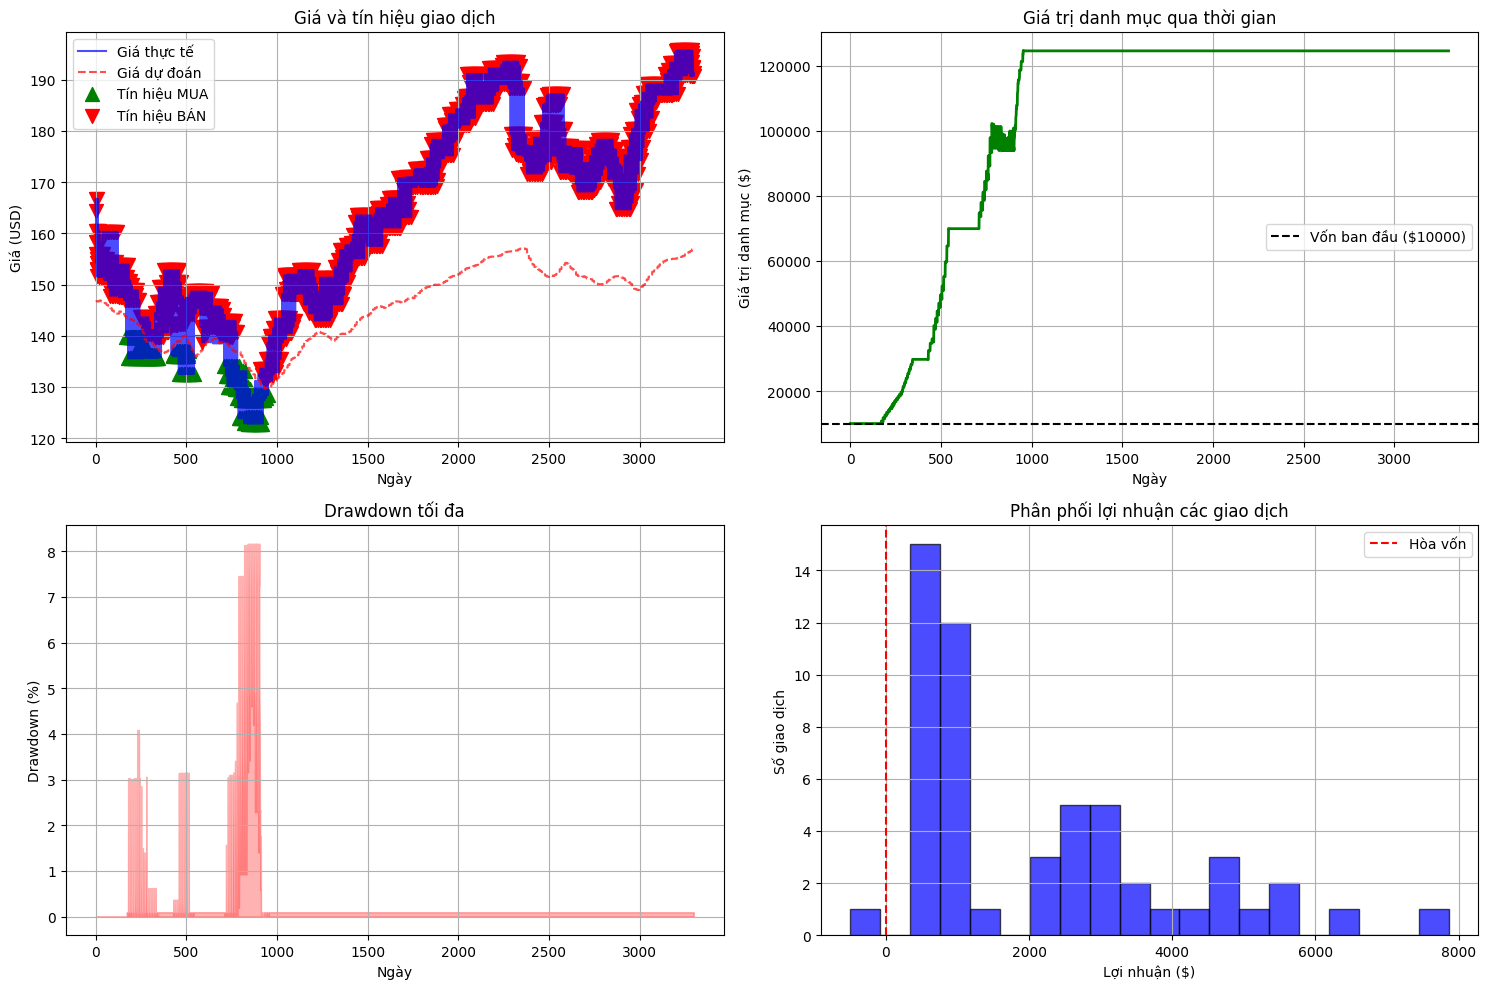

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Biểu đồ giá và tín hiệu giao dịch
ax1 = axes[0, 0]
ax1.plot(test_prices_original, label='Giá thực tế', color='blue', alpha=0.7)
ax1.plot(test_predictions_original, label='Giá dự đoán', color='red', alpha=0.7, linestyle='--')

# Đánh dấu các điểm mua/bán
buy_signals = np.where(signals == 1)[0]
sell_signals = np.where(signals == -1)[0]
ax1.scatter(buy_signals, test_prices_original[buy_signals],
           color='green', marker='^', s=100, label='Tín hiệu MUA')
ax1.scatter(sell_signals, test_prices_original[sell_signals],
           color='red', marker='v', s=100, label='Tín hiệu BÁN')

ax1.set_title('Giá và tín hiệu giao dịch')
ax1.set_xlabel('Ngày')
ax1.set_ylabel('Giá (USD)')
ax1.legend()
ax1.grid(True)

# 2. Biểu đồ tăng trưởng danh mục
ax2 = axes[0, 1]
ax2.plot(portfolio_values, color='green', linewidth=2)
ax2.axhline(y=backtester.initial_capital, color='black', linestyle='--',
           label=f'Vốn ban đầu (${backtester.initial_capital})')
ax2.set_title('Giá trị danh mục qua thời gian')
ax2.set_xlabel('Ngày')
ax2.set_ylabel('Giá trị danh mục ($)')
ax2.legend()
ax2.grid(True)

# 3. Biểu đồ Drawdown
ax3 = axes[1, 0]
rolling_max = np.maximum.accumulate(portfolio_values)
drawdown = (rolling_max - portfolio_values) / rolling_max * 100
ax3.fill_between(range(len(drawdown)), 0, drawdown, color='red', alpha=0.3)
ax3.set_title('Drawdown tối đa')
ax3.set_xlabel('Ngày')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True)

# 4. Phân phối lợi nhuận các giao dịch
ax4 = axes[1, 1]
if len(backtester.positions) > 0:
    profits = [p['profit'] for p in backtester.positions]
    ax4.hist(profits, bins=20, color='blue', alpha=0.7, edgecolor='black')
    ax4.axvline(x=0, color='red', linestyle='--', label='Hòa vốn')
    ax4.set_title('Phân phối lợi nhuận các giao dịch')
    ax4.set_xlabel('Lợi nhuận ($)')
    ax4.set_ylabel('Số giao dịch')
    ax4.legend()
    ax4.grid(True)
else:
    ax4.text(0.5, 0.5, 'Không có giao dịch nào',
            horizontalalignment='center', verticalalignment='center',
            transform=ax4.transAxes, fontsize=14)

plt.tight_layout()
plt.show()